### Introduction
This notebook steps through the analysis of the Libera science radiometer calibration in ERF. The LST calibration is also included since it was used during the IOV test, which was the final radiometric test of the instrument. The next block just loads the needed packages.

In [1]:
import erf_analysis as erf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The raw instrument data (ERF log files, laser spectra, MODTRAN scene files) is
# not in this repository - it is large and lives on LASP storage. Detected once
# here: the cells that re-reduce those files skip themselves with an explanation
# when it is absent, while everything downstream of the committed CSVs in data/
# runs either way. Set this False by hand to force the committed-CSV path even
# when the raw data is present.
raw_data_available = erf.raw_data_available()

### ERF Data Example
We'll first walk through an example ERF data file, detailing the analysis steps. The following cell analyzes a laser spectrum for a given ERF dataset, then loads and plots the radiance data from that dataset.

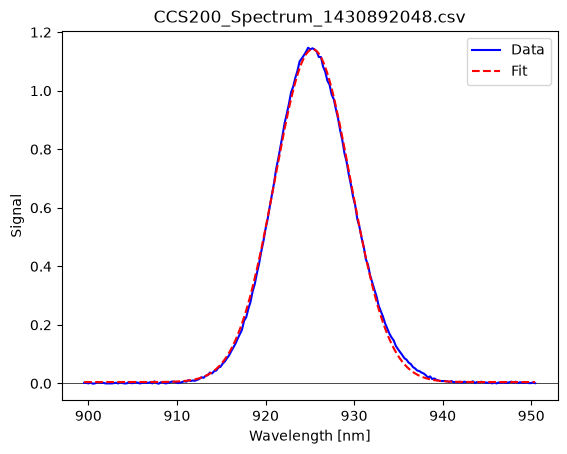

OPA Wavelength Setpoint = 0.925 nm, Fit Center = 926.05 +/- 0.13 nm, FWHM = 10.08 +/- 0.03 nm


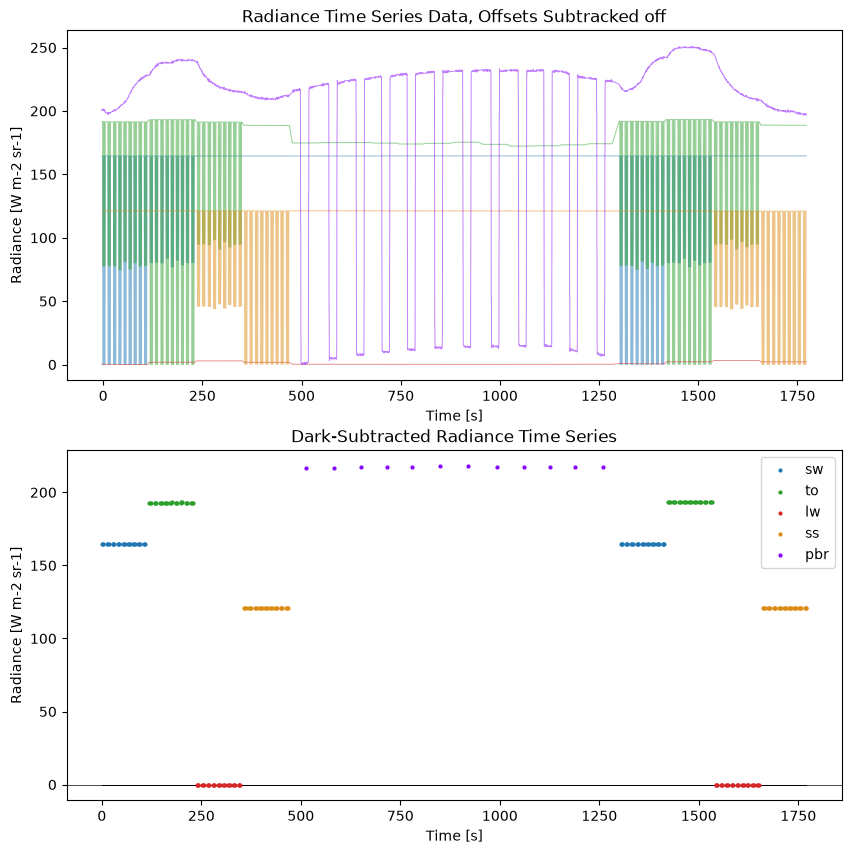

In [2]:
if raw_data_available:
    # Load the ERF summary data
    batch_file = 'libera_erf_sci_radiometers_cal_log.csv'
    paths = erf.load_config()
    f = erf.tidy_up_header(pd.read_csv(paths.erf_misc_file_dir / batch_file))

    # Choose this row as an example, this is a measurement of the science radiometer at 0.925 um
    irow = 835

    # First load and fit the laser spectrum
    wl_fit = erf.analyze_ccs200_spectrum(file=f["spectrum_file"].iloc[irow], 
                                         wavelength_um_opa=f["wavelength_um"].iloc[irow],
                                         show_plot=True)

    print(f'OPA Wavelength Setpoint = {f["wavelength_um"].iloc[irow]:0.3f} nm, '
          f'Fit Center = {wl_fit.wavelength_center_um*1e3:0.2f} +/- {wl_fit.wavelength_center_um_sd*1e3:0.2f} nm, '
          f'FWHM = {wl_fit.wavelength_fwhm_um*1e3:0.2f} +/- {wl_fit.wavelength_fwhm_um_sd*1e3:0.2f} nm')

    # This routine reads the file and does the DC subtraction
    df, meas_data, pbr_conv = erf.erf_log_file_read_and_parse(file=f["log_file"].iloc[irow],
                                                    ap_dia_mm=f["port_size_mm"].iloc[irow],
                                                    wavelength_um=wl_fit.wavelength_center_um,
                                                    fpe_name=f["driver"].iloc[irow])

    # Store the starting time, subtract this off the plots to just show seconds
    t0 = meas_data["gps_time_s"].iloc[0]
    meas_data["rel_time"] = meas_data["gps_time_s"] - t0
    df["rel_time"] = df["gps_time_s"] - t0

    # Plot the raw data and the 
    ch_list = ["sw", "to", "lw", "ss", "pbr"]
    col_list = ["l0_sw", "l1_to", "l2_lw", "l3_ss", "pbr_l"]
    colors = ['#1f77b4',  '#2ca02c', '#d62728', "#dc8c14", "#8300fd"]
    # Detector index mapping:
    #     0     PBR-R
    #     1     SSW
    #     2     LW
    #     3     Total
    #     4     SW
    det_index = [4, 3, 2, 1, 0]

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
    for ch, color, col_name in zip(ch_list, colors, col_list):
          ax1.plot(df["rel_time"],df[col_name] - df[col_name].min(),color=color,label=ch,linewidth=0.7,alpha=0.5)
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Radiance [W m-2 sr-1]')
    ax1.set_title('Radiance Time Series Data, Offsets Subtracked off')

    for ch, color, idet in zip(ch_list, colors, det_index):
          meas_data_tmp = meas_data.loc[(meas_data["detector_index"] == idet)]
          ax2.scatter(meas_data_tmp["rel_time"], meas_data_tmp["l"],color=color,s=4,label=ch,zorder=2)
    ax2.plot(meas_data["rel_time"],0*meas_data["l"],color='black',zorder=1,linewidth=0.7)
    ax2.axhline(0, color='black', linewidth=0.5, zorder=1)
    ax2.set_xlabel('Time [s]')
    ax2.set_ylabel('Radiance [W m-2 sr-1]')
    ax2.set_title('Dark-Subtracted Radiance Time Series')
    ax2.legend()
else:
    print("Skipped - this walkthrough reads one raw ERF log file and its laser\n"
          "          spectrum directly, so it needs the raw data. The radiance\n"
          "          field fit below uses the meas_data it builds and is skipped\n"
          "          too; the level_01 analysis and everything after it are\n"
          "          independent of both.")

Next we fit the dark-subtracted radiance data. The entire radiance dataset is fit at once. The radiance field is assumed to have linear gradients in X, Y, pitch and yaw direction, and a linear drift with time. The radiance level is determined from the PBR-R measurements, and then the response of the four science channels are part of the fit.


Gradient Fit Summary
                                               Description Variable  Fit Value  Uncertainty
Radiance at x=y=pitch=yaw=0, file's mean time [W m-2 sr-1]       l0 217.363797     0.034043
                           Radiance gradient per mm, x [%]       gx  -0.024326     0.002765
                           Radiance gradient per mm, y [%]       gy   0.007919     0.002766
                          Gradient per degree of pitch [%]       gp  -0.058475     0.015874
                            Gradient per degree of yaw [%]       gw  -0.020778     0.015874
                                      Drift per minute [%]       gt   0.001819     0.000069

Response Fit Summary:
Channel      r [%]  r_sd [%]  sigma [W m-2 sr-1]
     sw  75.635256  0.011890            0.015826
     to  88.826584  0.013961            0.018200
     lw   0.005497  0.000194            0.003032
     ss  55.644834  0.008743            0.010797
    pbr 100.000000  0.000000            0.115299



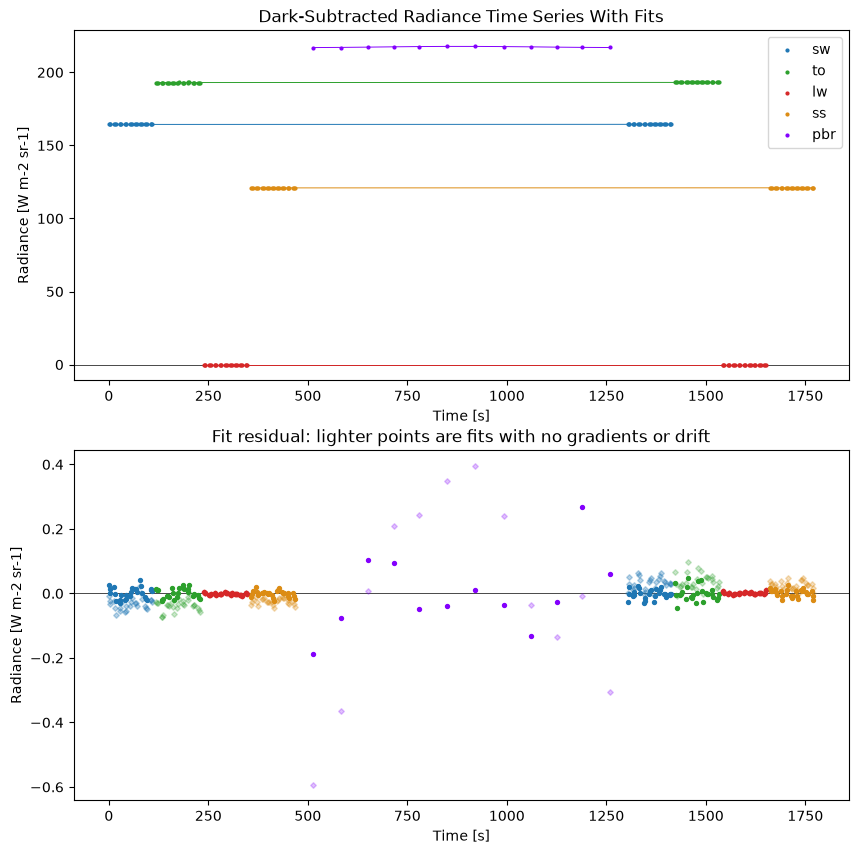

In [3]:
# Fits the radiance field of the single example measurement loaded above, so it
# needs that cell's meas_data and shares its raw-data dependency.
if raw_data_available:
    field0 = erf.fit_radiance_field(meas_data,fit_drift=False,fit_gradients=False)
    field  = erf.fit_radiance_field(meas_data)

    meas_data["fit_l0"] = field0.fit_output
    meas_data["fit_l0_residual"] = meas_data["l"] - meas_data["fit_l0"]

    meas_data["fit_l"] = field.fit_output
    meas_data["fit_l_residual"] = meas_data["l"] - meas_data["fit_l"]

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
    for ch, color, idet in zip(ch_list, colors, det_index):
        meas_data_tmp = meas_data.loc[(meas_data["detector_index"] == idet)]
        ax1.scatter(meas_data_tmp["rel_time"], meas_data_tmp["l"],color=color,s=4,label=ch,zorder=2)
        ax1.plot(meas_data_tmp["rel_time"], meas_data_tmp["fit_l"],color=color,linewidth=0.7)
    ax1.axhline(0, color='black', linewidth=0.5, zorder=1)
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Radiance [W m-2 sr-1]')
    ax1.set_title('Dark-Subtracted Radiance Time Series With Fits')
    ax1.legend()

    fit_l_residual = meas_data["l"] - field0.fit_output
    colors = ["#1f76b451",  "#2ca02c40", "#d6272741", "#dc8c1448", "#8300fd3d"]
    for ch, color, idet in zip(ch_list, colors, det_index):
        meas_data_tmp = meas_data.loc[(meas_data["detector_index"] == idet)]
        ax2.scatter(meas_data_tmp["rel_time"], meas_data_tmp["fit_l0_residual"],color=color,s=8,label=ch,zorder=2, marker='D')

    colors = ['#1f77b4',  '#2ca02c', '#d62728', "#dc8c14", "#8300fd"]
    for ch, color, idet in zip(ch_list, colors, det_index):
        meas_data_tmp = meas_data.loc[(meas_data["detector_index"] == idet)]
        ax2.scatter(meas_data_tmp["rel_time"], meas_data_tmp["fit_l_residual"],color=color,s=8,label=ch,zorder=2)    

    ax2.axhline(0, color='black', linewidth=0.5, zorder=1)
    ax2.set_xlabel('Time [s]')
    ax2.set_ylabel('Radiance [W m-2 sr-1]')
    ax2.set_title("Fit residual: lighter points are fits with no gradients or drift")

    # Table of the fit values and their 1-sigma uncertainties. l0 is an absolute
    # radiance, so it's left as-is; the g* terms are all fractional and small
    # enough that showing them as percent is more readable. gp/gw only exist
    # when share_angular=True and gt only when fit_drift=True (both defaults),
    # so those are pulled with getattr rather than assumed to always be present.
    field_table = pd.DataFrame([
        ("Radiance at x=y=pitch=yaw=0, file's mean time [W m-2 sr-1]", "l0", field.l0, field.l0_sd),
        ("Radiance gradient per mm, x [%]",                            "gx", 100*field.gx, 100*field.gx_sd),
        ("Radiance gradient per mm, y [%]",                            "gy", 100*field.gy, 100*field.gy_sd),
        ("Gradient per degree of pitch [%]",                           "gp", 100*getattr(field, "gp", np.nan), 100*getattr(field, "gp_sd", np.nan)),
        ("Gradient per degree of yaw [%]",                             "gw", 100*getattr(field, "gw", np.nan), 100*getattr(field, "gw_sd", np.nan)),
        ("Drift per minute [%]",                                       "gt", 100*field.gt, 100*field.gt_sd),
    ], columns=["Description", "Variable", "Fit Value", "Uncertainty"])

    print()
    print('Gradient Fit Summary')
    print(field_table.to_string(index=False))

    # Per-channel fit response (relative to PBR-R) and noise, one row per
    # science channel plus PBR-R itself. r/r_sd are fractional (r=1 means the
    # channel reads the same radiance as PBR-R) so shown as percent; sigma is
    # the fitted per-detector noise level, in the same radiance units as the
    # data itself.
    response_table = pd.DataFrame([
        (ch, 100*field.r[idet], 100*field.r_sd[idet], field.sigma[idet])
        for ch, idet in zip(ch_list, det_index)
    ], columns=["Channel", "r [%]", "r_sd [%]", "sigma [W m-2 sr-1]"])

    print()
    print('Response Fit Summary:')
    print(response_table.to_string(index=False))

    print()
else:
    print("Skipped - fits the radiance field of the example measurement loaded\n"
          "          in the cell above, which needs the raw data.")

This is the fitting that is performed for each ERF file. 

### Level 1 Analysis
In the next block each ERF file for the science radiometers and the LST is and csv summary files "Libera_ERF_analysis_summary_level_01.csv" and "Libera_ERF_LST_analysis_summary_level_01.csv" are written to paths.analysis_dir. Downstream analysis just uses this summary data.

In [4]:
# Re-runs the level_01 reduction over every ERF log file. This takes some time
# and needs the raw data; set analyze_erf_files False to skip it even when the
# raw data is present, since its outputs are committed in data/.
analyze_erf_files = True

if analyze_erf_files and raw_data_available:
    erf.science_radiometer_analyze_level_01()
    erf.lst_analyze_level_01()
else:
    print("Skipped - regenerates data/Libera_ERF_analysis_summary_level_01.csv and\n"
          "          data/Libera_ERF_LST_analysis_summary_level_01.csv, both of\n"
          "          which are committed. The cells below read those files.")


Analysis summary:
   0, ERF_Log_File_20240726_1355.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
   1, ERF_Log_File_20240729_0803.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
   2, ERF_Log_File_20240729_0907.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
   3, ERF_Log_File_20240729_1120.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
   4, ERF_Log_File_20240729_1151.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
   5, ERF_Log_File_20240729_1227.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
   6, ERF_Log_File_20240729_1318.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
   7, ERF_Log_File_20240729_1542.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
   8, ERF_Log_File_20240729_1612.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
   9, ERF_Log_File_20240730_0905.csv, OPA Wl =  2.500 um, Wl =  2.500 um, FWHM = 0.0000 um
  10, ERF_Log_File_20240730_0940.csv, OPA Wl =  3.000 um, Wl =  3.000 u

First we'll make plots covering the full range of the science radiometer data. First we'll plot the wavelength measured by the grating spectrometer compared to the Thorlabs Optical Spectrum Analyzer (OSA) spectrometer. The OSA uses as reference laser and so has a accuracy of 2 ppm. However, OSA spectrometer only works out to ~13 um, and so we need to rely on the grating spectrometer to cover out to 16um. This code to verifies it's wavelength scaling.

A side note, we have verified that the OSA wavelength scale is very accurate, both from its specifications and independently by looking at optical absoprtion lines we observe (at certain wavelengths parts of the laser spectrum are absorbed by CO2 and H2O in the room). We have found, however, that in the IR (largely >2um) there is a spatial chirp in the laser beam, as so the part of the beam that the OSA measures won't perfectly match the beam that enters the ERF source integrating sphere. This causes a small relative shift in the actual laser wavelength relative to the what the OSA measures, and this shift changes with each test campaign because the OSA alignment gets adjusted. We detector these shifts by the 4um cutoff edge of the SSW and SW channels, and the 5um cuton edge of the LW. 

Estimated Grating Wavelength Error = 0.221um


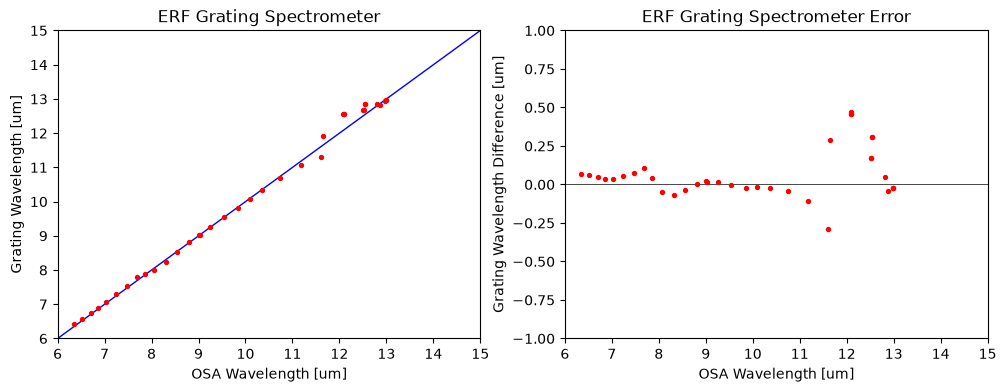

In [5]:
# Load the level 1 data
paths = erf.load_config()
filename = "Libera_ERF_analysis_summary_level_01.csv"
df = erf.tidy_up_header(pd.read_csv(paths.analysis_dir / filename))

# Sort by wavelength
df.sort_values(by="wavelength_um", inplace=True)

# Get the data points with a grating wavelength
df = df.loc[(df["wavelength_um_grating"] != 0) & (df["wavelength_source"] == 2)]

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
ax1.plot([6,15],[6,15],color='blue', zorder=1, linewidth=1)
ax1.scatter(df["wavelength_um"], df["wavelength_um_grating"], color='red', s=8, zorder=2)
ax1.set_title('ERF Grating Spectrometer')
ax1.set_xlabel('OSA Wavelength [um]')
ax1.set_ylabel('Grating Wavelength [um]')
ax1.set_xlim(6,15)
ax1.set_ylim(6,15)

df['wl_error'] = df["wavelength_um_grating"] - df["wavelength_um"]
ax2.axhline(0, color='black', linewidth=0.5, zorder=1)
ax2.scatter(df["wavelength_um"], df['wl_error'], color='red', s=8, zorder=2)
ax2.set_title('ERF Grating Spectrometer Error')
ax2.set_xlabel('OSA Wavelength [um]')
ax2.set_ylabel('Grating Wavelength Difference [um]')
ax2.set_xlim(6,15)
ax2.set_ylim(-1,1)

# Calculate the error for wavelength greater than 10um
df = df.loc[df["wavelength_um"] >= 10]
print(f"Estimated Grating Wavelength Error = {(df['wl_error'].std()):0.3f}um")

Next we plot the temperature of the telescope optical bench (which also holds the detectors) for all of the measurements. The nominal measurement temperature is 34.17C, but measurements were taken at lower temperatures as well. For the initial analysis we'll use the data between 32C and 35C. The 29C measurements were taken to test for temperature sensitivity of the SRF features, only the SSW 0.74um cuton edge was observed to exhibit a temperature effect, which is cahracterized and corrected for in the analysis code.

Text(0, 0.5, 'Number of Measurements')

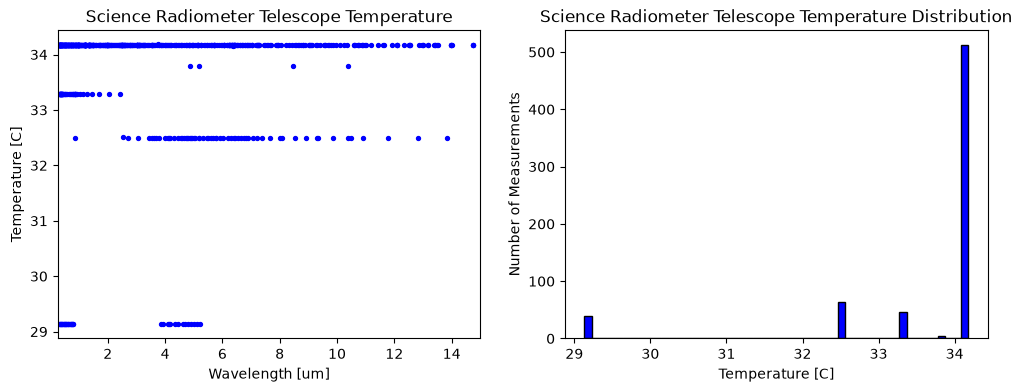

In [6]:
# Load the level 1 data
paths = erf.load_config()
filename = "Libera_ERF_analysis_summary_level_01.csv"
df = erf.tidy_up_header(pd.read_csv(paths.analysis_dir / filename))

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
ax1.scatter(df["wavelength_um"], df["sci_rad_bench_temp_c"], color='blue', s=8, zorder=2)
ax1.set_title('Science Radiometer Telescope Temperature')
ax1.set_xlabel('Wavelength [um]')
ax1.set_ylabel('Temperature [C]')
ax1.set_xlim(0.25,15)

# Histogram of the bench temperature, showing the number of measurements
# in each of the ~5 distinct temperature populations (e.g. setpoints used
# across different measurement campaigns).
ax2.hist(df["sci_rad_bench_temp_c"], bins=50, color='blue', edgecolor='black')
ax2.set_title('Science Radiometer Telescope Temperature Distribution')
ax2.set_xlabel('Temperature [C]')
ax2.set_ylabel('Number of Measurements')

Next we'll just plot at the PBR-R radiance level vs wavelength for all measurements. I created a lower radiance limit to throw out any measurement taken in the middle of the wavelength range that have very low radiance. We allow radiance at the shorted and longest wavelengths where we at the limits of the laser system. 

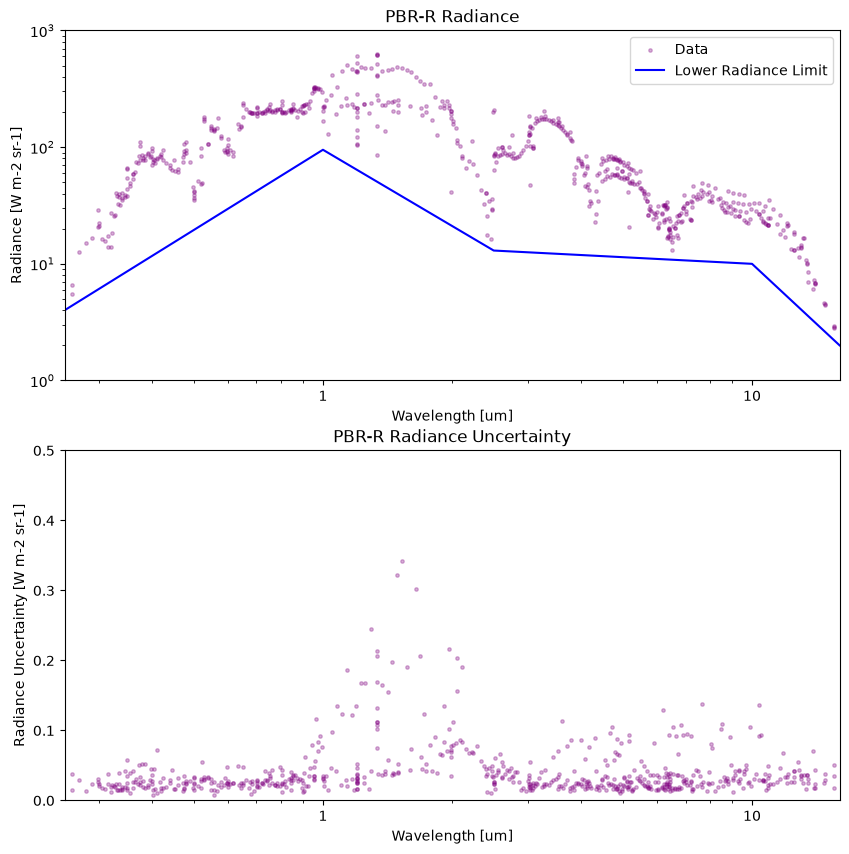

In [7]:
# Load the level 1 data
paths = erf.load_config()
filename = "Libera_ERF_analysis_summary_level_01.csv"
df = erf.tidy_up_header(pd.read_csv(paths.analysis_dir / filename))

# Sort by wavelength
df.sort_values(by="wavelength_um", inplace=True)

# This is the lower limit threshold:
wl_lmin = [0.25,  1.0,  2.5, 10.0, 16.0]
lmin =    [4.00, 95.0, 13.0, 10.0,  2.0] 

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
ax1.scatter(df["wavelength_um"], df["gf_l0"], color='purple', s=6, alpha=0.3, label='Data')
ax1.plot(wl_lmin,lmin,color='blue',label='Lower Radiance Limit')
ax1.set_title('PBR-R Radiance')
ax1.set_xlabel('Wavelength [um]')
ax1.set_ylabel('Radiance [W m-2 sr-1]')
ax1.set_xlim(0.25,16)
ax1.set_ylim(1,1e3)
erf.log_x_axis_decimal(ax1)
ax1.set_yscale('log')
ax1.legend()

ax2.scatter(df["wavelength_um"], df["gf_l0_sd"], color='purple', s=6, alpha=0.3)
ax2.set_title('PBR-R Radiance Uncertainty')
ax2.set_xlabel('Wavelength [um]')
ax2.set_ylabel('Radiance Uncertainty [W m-2 sr-1]')
ax2.set_xlim(0.25,16)
ax2.set_ylim(0,0.5)
erf.log_x_axis_decimal(ax2)


Next we'll plot the measured laser linewidth FWHM versus wavelength and the relative linewidth (the percent the FWHM is of the total linewdith). Note that the relative linewdith itself grows with wavelength, and varies from 0.5% in the UV to 10% by 14 um.

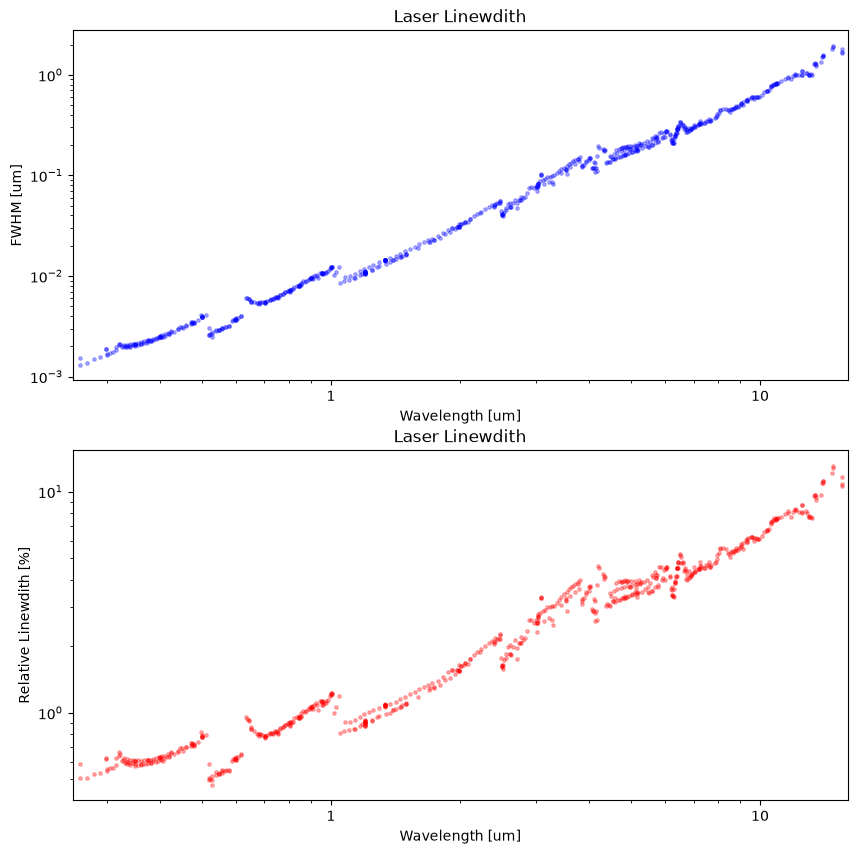

In [8]:
# Load the level 1 data
paths = erf.load_config()
filename = "Libera_ERF_analysis_summary_level_01.csv"
df = erf.tidy_up_header(pd.read_csv(paths.analysis_dir / filename))

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))
ax1.scatter(df["wavelength_um"], df["wavelength_um_fwhm"], color='blue', s=6, alpha=0.3)
ax1.set_title('Laser Linewdith')
ax1.set_xlabel('Wavelength [um]')
ax1.set_ylabel('FWHM [um]')
ax1.set_xlim(0.25,16)
erf.log_x_axis_decimal(ax1)
ax1.set_yscale('log')

ax2.scatter(df["wavelength_um"], 100*df["wavelength_um_fwhm"]/df["wavelength_um"], color='red', s=6, alpha=0.3)
ax2.set_title('Laser Linewdith')
ax2.set_xlabel('Wavelength [um]')
ax2.set_ylabel('Relative Linewdith [%]')
ax2.set_xlim(0.25,16)
erf.log_x_axis_decimal(ax2)
ax2.set_yscale('log')


Next we'll plot all the fitted response ratios (relative to PBR-R) from the ERF measureuents.

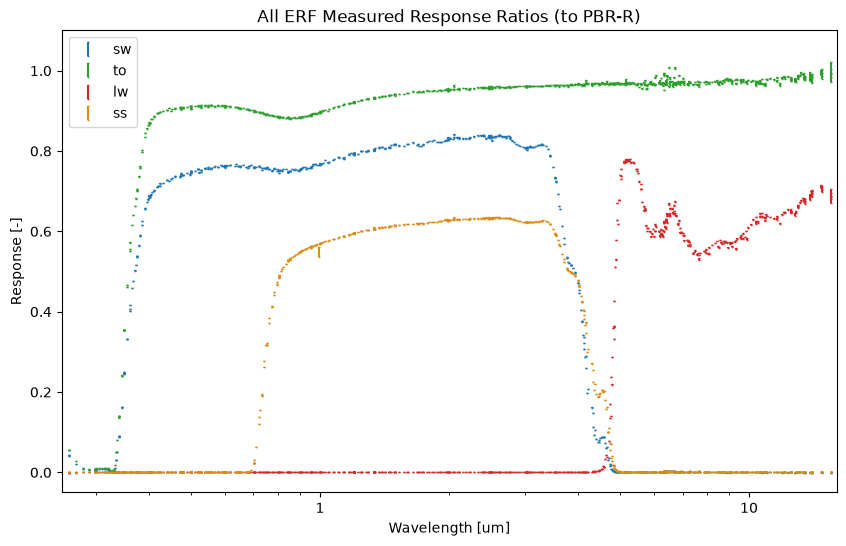

In [9]:
# Load the level 1 data
paths = erf.load_config()
filename = "Libera_ERF_analysis_summary_level_01.csv"
df = erf.tidy_up_header(pd.read_csv(paths.analysis_dir / filename))

# Sort by wavelength
df.sort_values(by="wavelength_um", inplace=True)

colors = ['#1f77b4',  '#2ca02c', '#d62728', "#dc8c14"]
ch_list = ["sw","to","lw","ss"]
fig, ax = plt.subplots(figsize=(10, 6))
for ch, color in zip(ch_list, colors):
    ax.errorbar(df["wavelength_um"],df[f"gf_resp_{ch}"],
                yerr=df[f"gf_resp_sd_{ch}"],color=color,
                fmt='none', capsize=0.5, label=ch)
erf.log_x_axis_decimal(ax)
ax.set_xlim(0.25,16)
ax.set_ylim(-0.05,1.1)
ax.set_xlabel("Wavelength [um]")
ax.set_ylabel("Response [-]")
ax.set_title("All ERF Measured Response Ratios (to PBR-R)")
ax.legend()


### Level 2 Analysis
For the next level of analysis we load the "Libera_ERF_analysis_summary_level_01.csv" (and "Libera_ERF_LST_analysis_summary_level_01.csv") and start working with the measured responses of each channel. The out of field correction is applied (see erf_scirad_scattered_light.ipynb), the uncertainty terms are collected. There are small offsets for each channel between each measurement campaign (Fall 2024 pre-SDL, February 2025 post-SDL, May 2025 with). The final measurement campaign (May 2025) is selected as the "truth" and individually each channel in the other two measurement campaigns are iteratively adjusted with a multiplicative offset for response, and smaller correction for the wavelength scale error in the IR, and then the spectral response functions are determined from the data using a penalized spline fit on a grid of wavelength nodes chosen for each channel.

SSW AMTIR-1 edge temperature correction: 10 of 600 points corrected, max 2.76e-03 SRF; uncertainty envelope at dT = 1.67C

Per-campaign FRACTIONAL wavelength offset [x1e-3], by outer iteration (referenced to the unweighted campaign mean; x4.6 for nm at the 4-5um anchor):
 iter      camp 0      camp 1      camp 2    spread
    0        0.00        0.00        0.00      0.00
    1        2.76       -0.12       -2.64      5.40
    2        2.60       -0.73       -1.88      4.48
    3        2.67       -0.91       -1.76      4.43
    4        2.73       -1.01       -1.72      4.44
    5        2.77       -1.07       -1.70      4.46

Offset by channel [x1e-3] - the cross-channel spread is the beam-error vs filter-ageing discriminator:
    ch      camp 0      camp 1      camp 2            n edge pts
    sw        2.40       -1.15       -1.25   {0: 15, 1: 5, 2: 8}
    to          --          --          --   {0: 0, 1: 0, 2: 0}
    lw        3.15          --       -2.08   {0: 15, 1: 1, 2: 9}
 

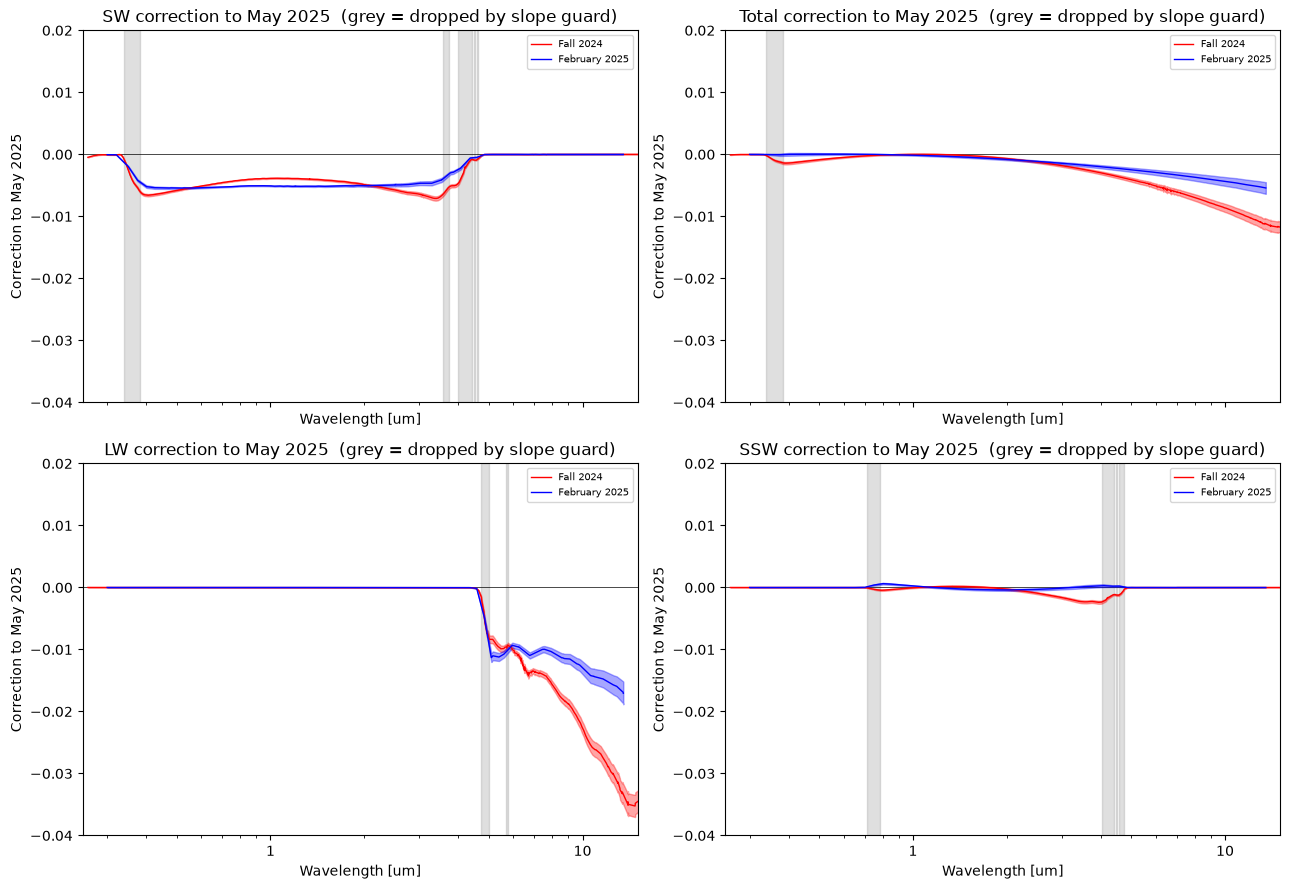

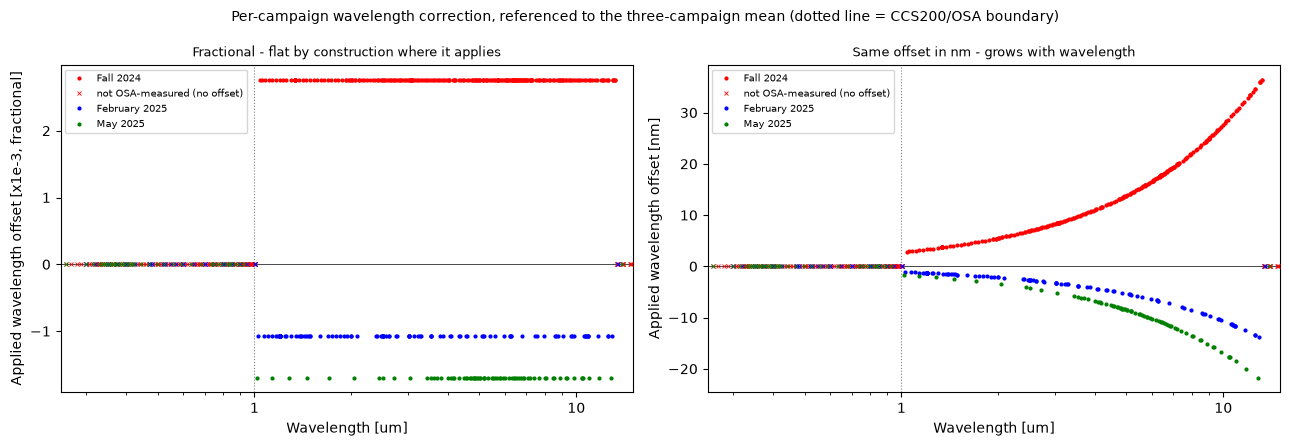

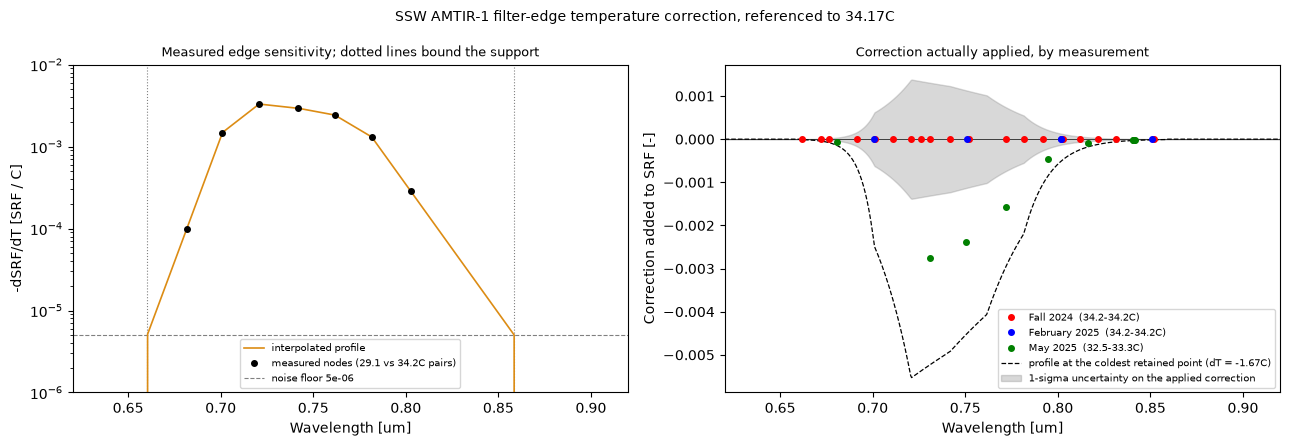

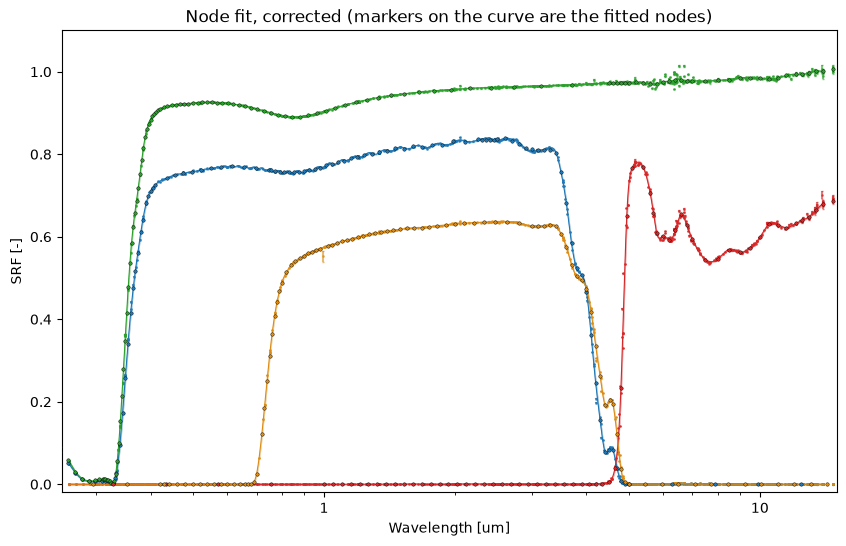

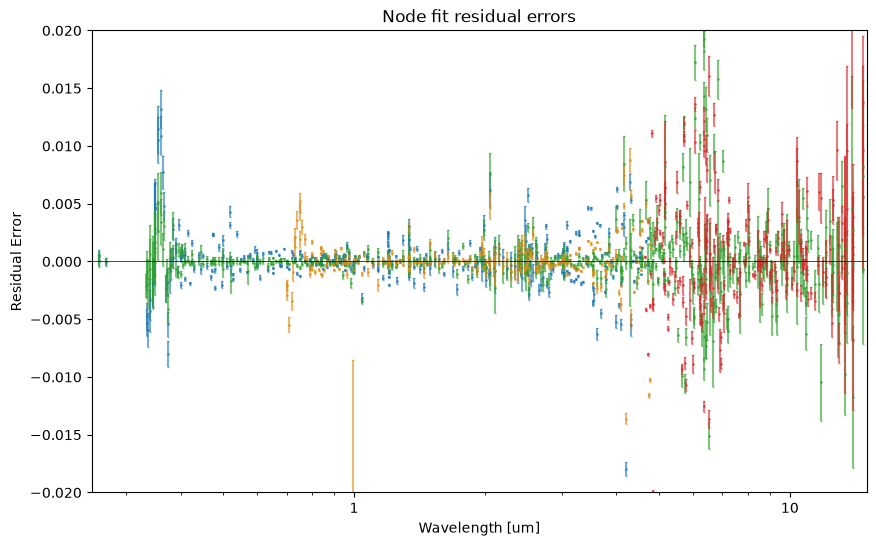

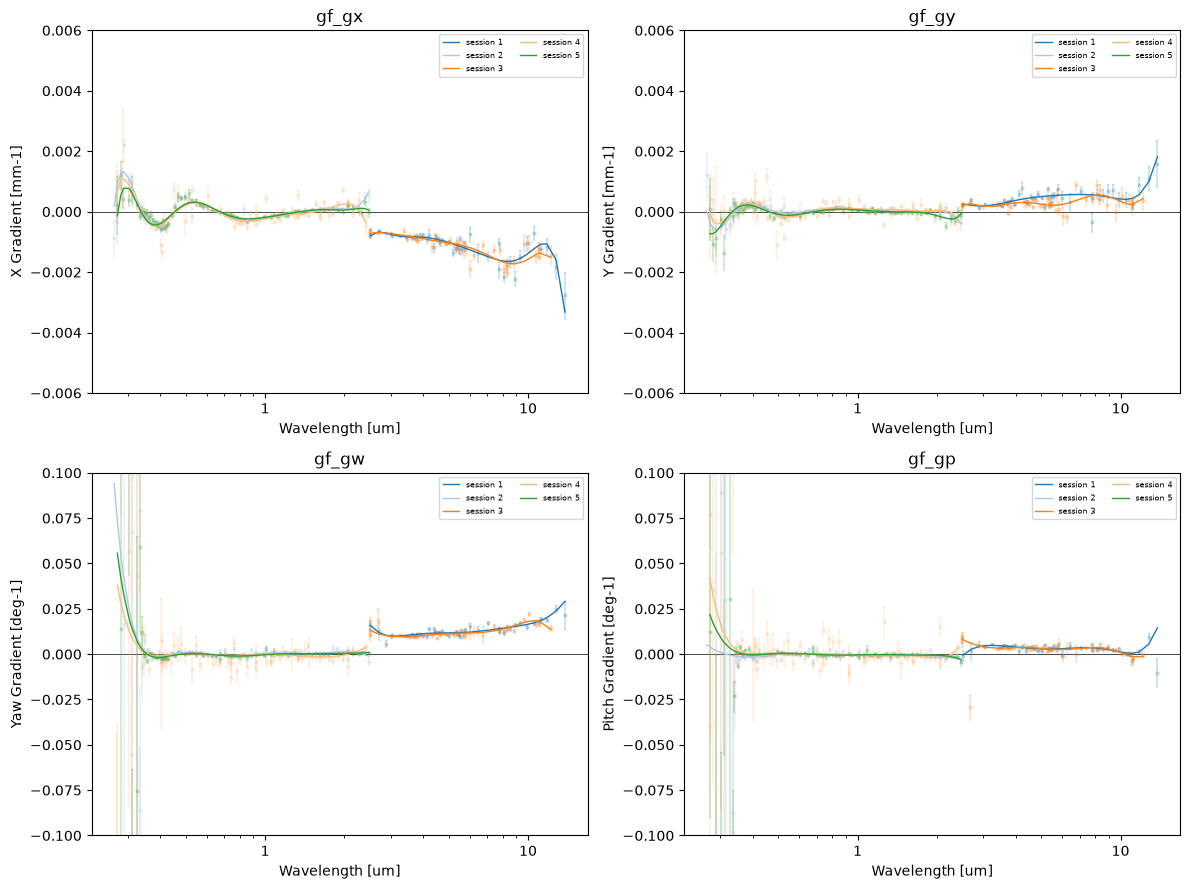

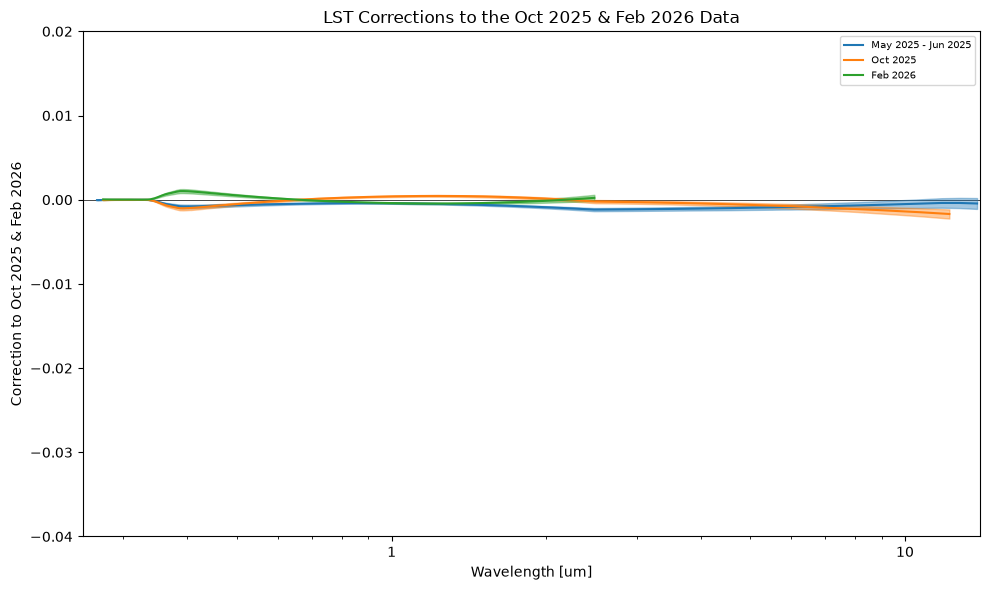

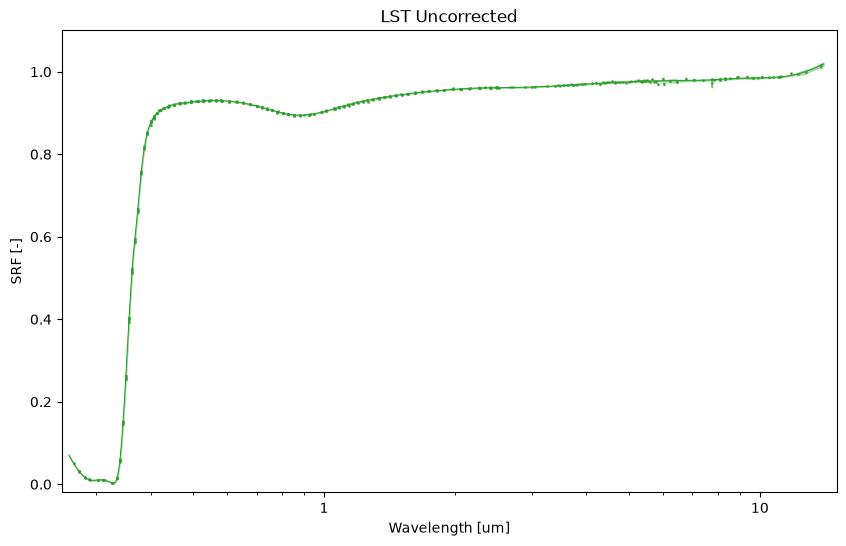

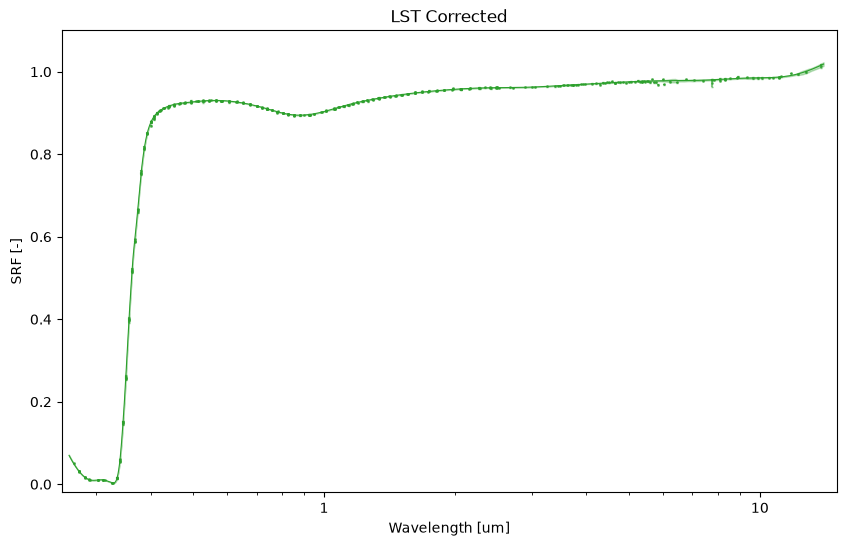

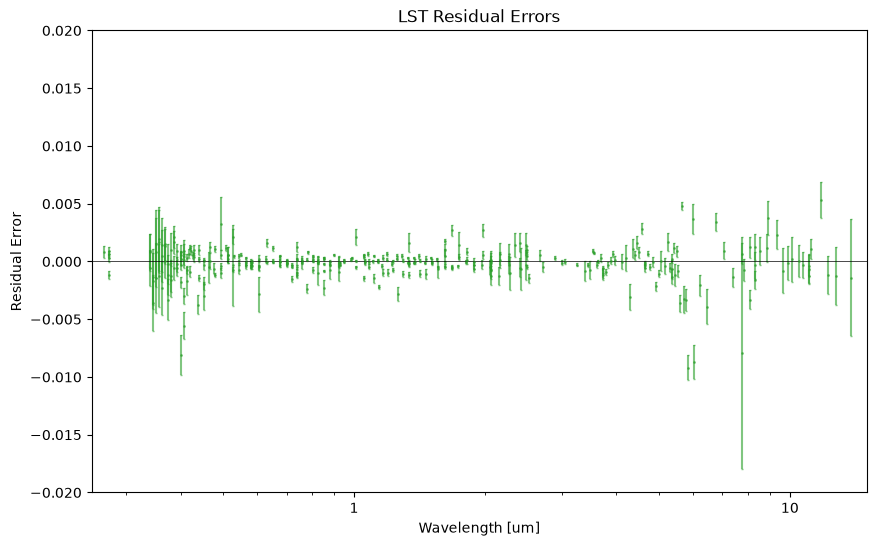

In [10]:
# Perform the level 2 analysis
erf.science_radiometer_analyze_level_02()
erf.lst_analyze_level_02()

### Split-SW Turn-On Edge
Before we present the uncertainty analysis we'll look at the SSW turn on, this will then flow into the SSW channel unfiltering analysis. We're looking for the approximate 50% point for the lower wavelength edge of the SSW passband.

SSW response crosses 0.275 at: 0.7440 um


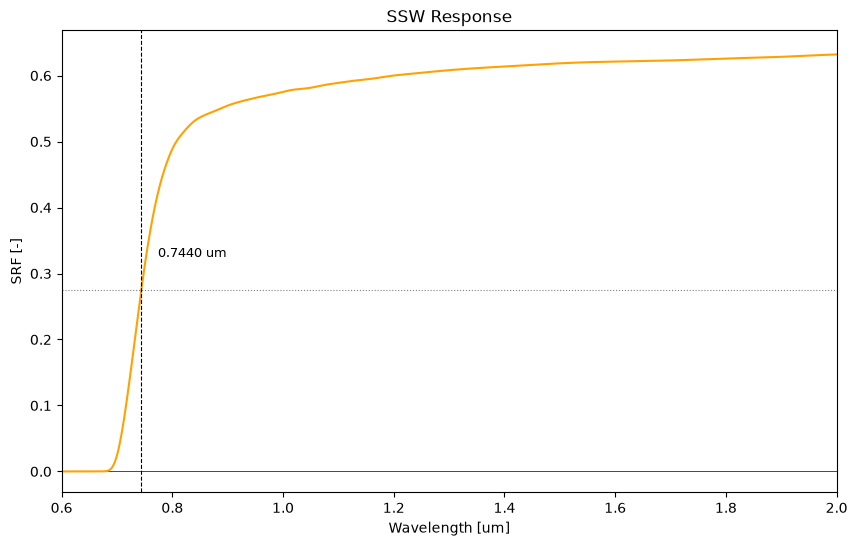

In [11]:
# Load the level 2 srfs
paths = erf.load_config()
filename = "Libera_erf_srfs_02.csv"

srf = erf.tidy_up_header(pd.read_csv(paths.analysis_dir / filename))

color = "#ffa200"
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(srf["wavelength_um"],srf["ss"],color=color)
ax.set_xlim(0.6,2)
ax.set_xlabel("Wavelength [um]")
ax.set_ylabel("SRF [-]")
ax.set_title("SSW Response")
ax.axhline(0, color='black', linewidth=0.5, zorder=1)

# Find where the SSW response crosses the turn-on midpoint level (0.275),
# restricted to the plotted range so we only pick up the turn-on edge
# itself rather than some other crossing elsewhere in the spectrum.
level = 0.275
mask = (srf["wavelength_um"] >= 0.6) & (srf["wavelength_um"] <= 2)
wl_range = srf.loc[mask, "wavelength_um"].values
ss_range = srf.loc[mask, "ss"].values

# A sign change in (ss - level) between two adjacent points means the curve
# crossed level somewhere between them; linearly interpolate for a more
# precise crossing wavelength than just taking the nearest grid point.
sign_change = np.diff(np.sign(ss_range - level)) != 0
crossing_wavelengths = []
for i in np.where(sign_change)[0]:
    x0, x1 = wl_range[i], wl_range[i + 1]
    y0, y1 = ss_range[i], ss_range[i + 1]
    crossing_wavelengths.append(x0 + (level - y0) * (x1 - x0) / (y1 - y0))

print(f"SSW response crosses {level} at: " + ", ".join(f"{w:.4f} um" for w in crossing_wavelengths))

ax.axhline(level, color='gray', linestyle=':', linewidth=0.8)
for w in crossing_wavelengths:
    ax.axvline(w, color='black', linestyle='--', linewidth=0.8)
    ax.annotate(f"{w:.4f} um", xy=(w, level), xytext=(w + 0.03, level + 0.05),
                fontsize=9, color='black')


### Level 3 Analysis
For level 3 analysis we now start with the result of the SRF fits from the level 2 analysis, and then we combine all errors at each wavelength to develop an uncertainty at each wavelength for each channel.





Done!


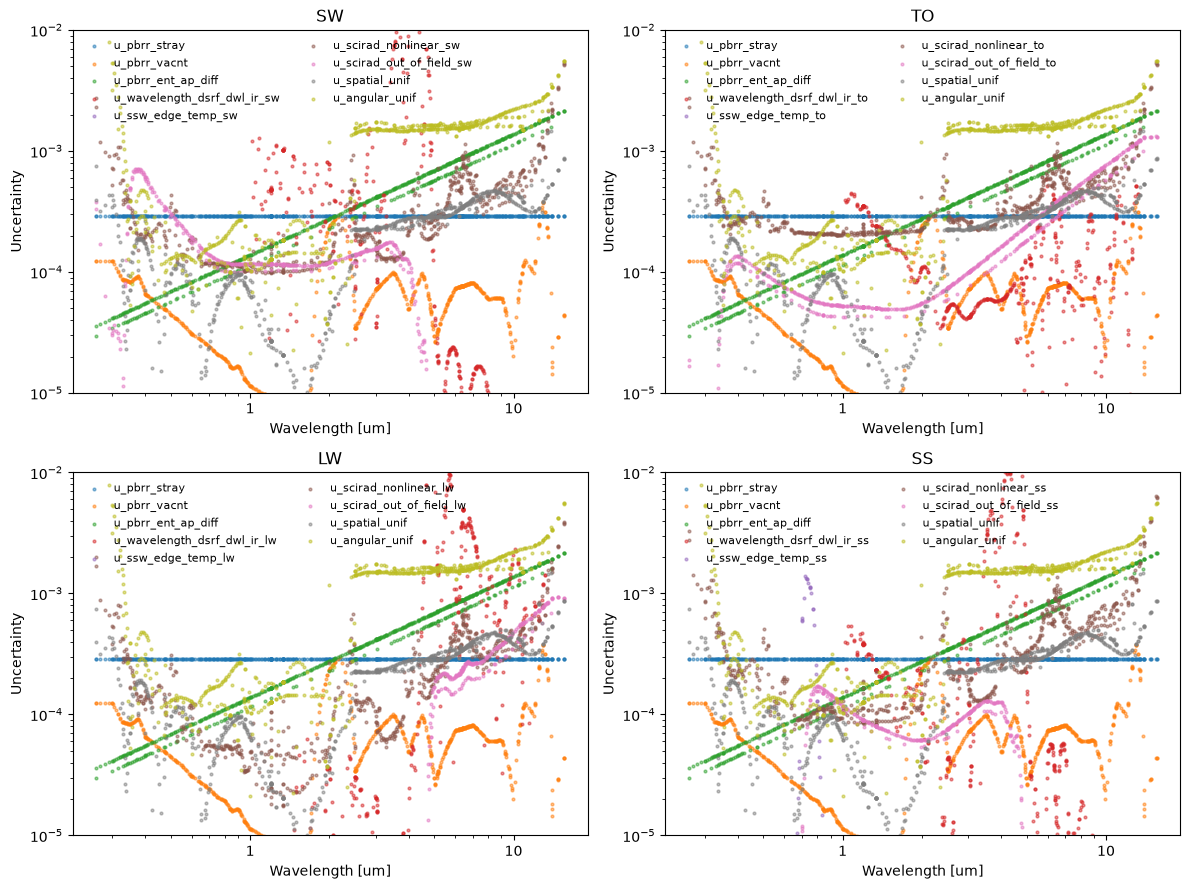

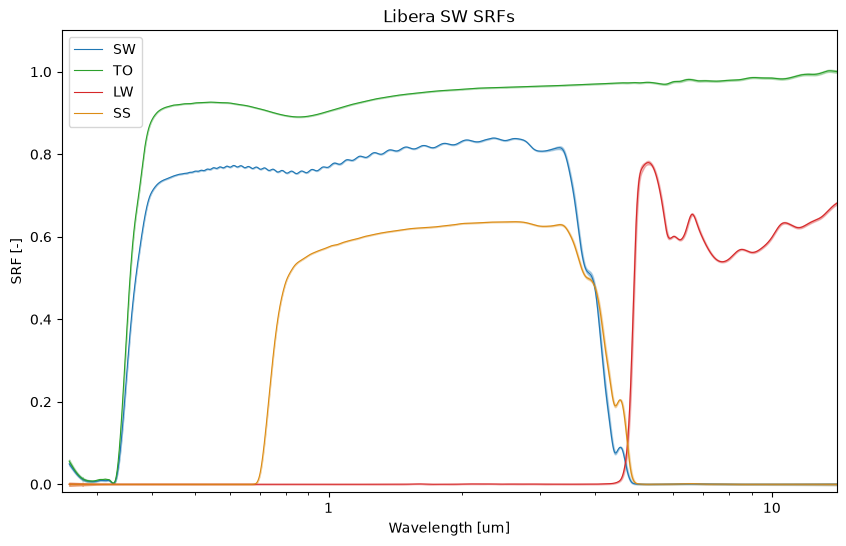

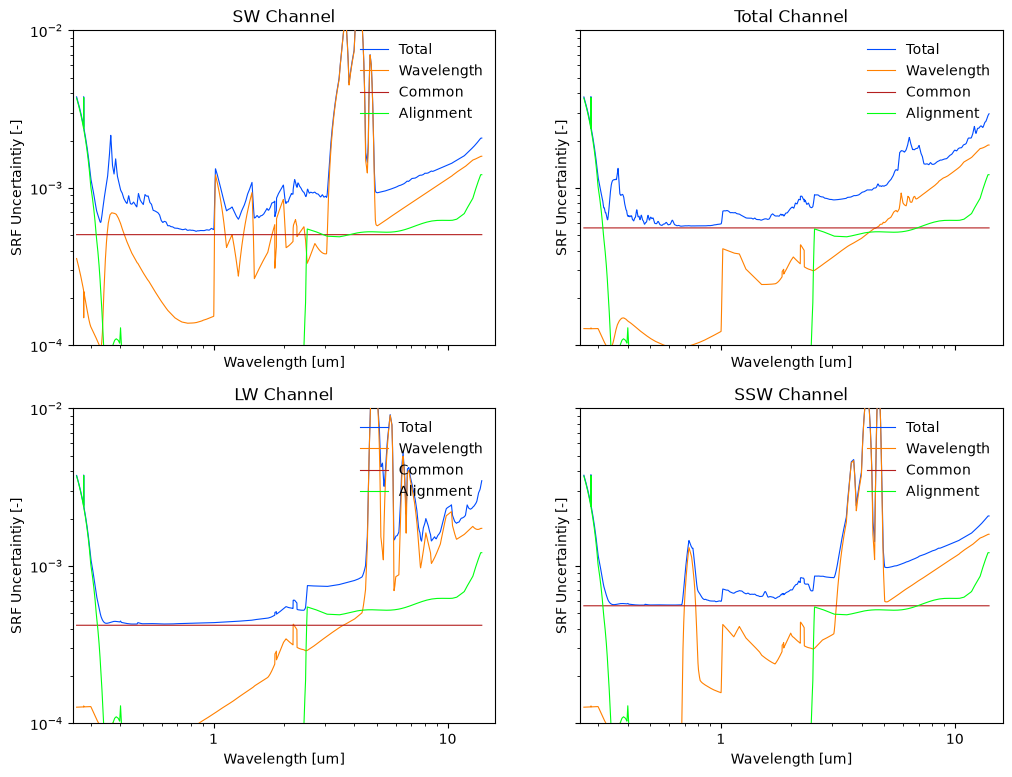

In [12]:
# Perform the level 3 analysis
erf.science_radiometer_analyze_level_03()

### Uncertainty for example scenes
With the wavelength dependent uncertainty generated by the level 3 analysis we then can calculate the uncertainty for several representaitve spectral scenes. For each scene and each channel we perform a weighted average of the wavelength dependent uncertainty using the spectral radiance of the scene as the weighting factor. 

Scene type: snow
scene channel  l_filtered_w_m2_sr  l_unfiltered_w_m2_sr  dl_w_m2_sr  relative_impact_pct
scene      SW          167.621556            229.612926    0.171073             0.102059
scene   Total          201.473134            229.612926    0.147158             0.073041
scene     SSW           43.064640             77.031798    0.151646             0.352136
Done!

Scene type: dc
scene channel  l_filtered_w_m2_sr  l_unfiltered_w_m2_sr  dl_w_m2_sr  relative_impact_pct
scene      SW          140.524580            192.133186    0.141008             0.100344
scene   Total          168.526764            192.133186    0.122651             0.072778
scene     SSW           39.698725             70.935190    0.127498             0.321163
Done!

Scene type: land
scene channel  l_filtered_w_m2_sr  l_unfiltered_w_m2_sr  dl_w_m2_sr  relative_impact_pct
scene      SW           56.104575             76.722057    0.064268             0.114550
scene   Total           67.790748             7

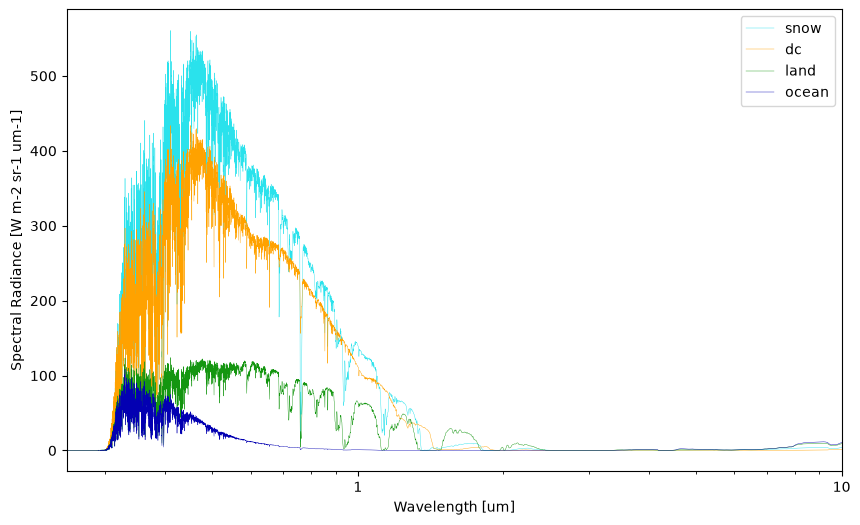

In [13]:
# Load the SRFs
# paths = erf.load_config()
# filename = "libera_erf_srfs_04.csv"
# srf = erf.tidy_up_header(pd.read_csv(paths.analysis_dir / filename))

names = ["snow","dc","land","ocean"]
colors = ["#2ae2ec", "#ffa200", "#149610", "#0300b2"]
fig, ax = plt.subplots(figsize=(10, 6))
for name, color in zip(names,colors):
    print(f"Scene type: {name}")
    spec = erf.tidy_up_header(pd.read_csv(paths.analysis_dir / f"erf_ceres_scene_{name}.csv"))
    uc = erf.science_radiometer_estimate_sw_uncertainty(wavelength_um=spec["wavelength_um"], 
                                                        radiance_w_m2_sr_um=spec["radiance_w_m2_sr_um"])
    ax.plot(spec["wavelength_um"],spec["radiance_w_m2_sr_um"],color=color,label=name,linewidth=0.3)
    print()

ax.set_xlim(0.25,10)
erf.log_x_axis_decimal(ax)
ax.set_xlabel("Wavelength [um]")
ax.set_ylabel("Spectral Radiance [W m-2 sr-1 um-1]")
ax.legend()
